# Develop quick stuff

For temporary/quick stuff to be developed

In [1]:
import os
import sys

base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)

from IPython.display import display, Markdown
import torch

from berebasl.simulation.credit_data_simulation import CreditDataGenerator, CreditData
from thesis.helper_scripts.general import extract_objs_from_sim_dir
from thesis.helper_scripts.hypothesis_visualization import (
  plot_lines_and_mains,
  generate_line_collections_for_exp_real_plot,
  generate_lines_for_diffs,
  gen_lines_from_diff_dict
)

grid_path = '../berebasl/data/simulations/mnar_grid_hyp_testing'
base_sim = 'bias_0_0_corr_0_0'

base_sim_objs = extract_objs_from_sim_dir(grid_path, base_sim)
dgp_base: CreditDataGenerator = base_sim_objs["data_generator"]

In [37]:
biases = {}
corrs = {}

corr_ider ="_corr_"
len_corr = len(corr_ider)
bias_ider = "bias_"
len_bias=len(bias_ider)

for sim_name in os.listdir(grid_path):
    corr_pos = sim_name.find(corr_ider)

    b = sim_name[len_bias:corr_pos]
    if b not in biases:
        biases[b] = float(b.replace('_', '.'))

    c = sim_name[corr_pos+len_corr:]
    if c not in corrs:
        corrs[c] = float(c.replace('_', '.'))

In [78]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from typing import Dict, Tuple, Callable, Optional


def extract_biases_and_corrs_from_dirnames(dir_path: str) -> Tuple[Dict[str, float], Dict[str, float]]:
    """
    Extract bias and correlation dictionaries from directory names.
    
    Args:
        dir_path: Path to directory containing simulation folders
        
    Returns:
        Tuple of (biases_dict, corrs_dict) where keys are string representations
        and values are float values
    """
    biases = {}
    corrs = {}
    
    corr_ider = "_corr_"
    len_corr = len(corr_ider)
    bias_ider = "bias_"
    len_bias = len(bias_ider)
    
    for sim_name in os.listdir(dir_path):
        corr_pos = sim_name.find(corr_ider)
        if corr_pos == -1:
            continue
            
        b = sim_name[len_bias:corr_pos]
        if b not in biases:
            biases[b] = float(b.replace('_', '.'))
        
        c = sim_name[corr_pos + len_corr:]
        if c not in corrs:
            corrs[c] = float(c.replace('_', '.'))
    
    return biases, corrs


def construct_all_diffs_tensor(
    grid_path: str,
    biases: Dict[str, float],
    corrs: Dict[str, float],
    expectation_types: list,
    metric_categories: list,
    diff_types: list,
    sample_sizes: torch.Tensor
) -> Tuple[torch.Tensor, int, int, int, int, int]:
    """
    Construct the all_diffs tensor by iterating over parameter combinations.
    
    Args:
        grid_path: Path to simulation directory
        biases: Dictionary of bias values
        corrs: Dictionary of correlation values
        expectation_types: List of expectation types
        metric_categories: List of metric categories
        diff_types: List of diff types
        sample_sizes: Tensor of sample sizes
        
    Returns:
        Tuple of (all_diffs_tensor, B, Co, E, M, D) with shapes and counts
    """
    all_diffs = []
    
    for b_s in biases.keys():
        for c_s in corrs.keys():
            sim_objs = extract_objs_from_sim_dir(grid_path, f"bias_{b_s}_corr_{c_s}")
            exp_to_real_diffs = generate_lines_for_diffs(sim_objs, make_abs=True, W=5)
            
            for e in expectation_types:
                for m in metric_categories:
                    case_lbl = e + '_' + m
                    case_data = exp_to_real_diffs["diff_data"][case_lbl]
                    
                    for classif in ["logit", "bayes"]:
                        for dt in diff_types:
                            all_diffs.append(case_data[classif][dt])
    
    B = len(biases)
    Co = len(corrs)
    E = len(expectation_types)
    M = len(metric_categories)
    Cl = 2  # logit, bayes
    D = len(diff_types)
    N = sample_sizes.size(0)
    
    all_diffs = torch.stack(all_diffs, dim=0).reshape(B, Co, E, M, Cl, D, N)
    return all_diffs, B, Co, E, M, D


def get_areas(
    all_diffs: torch.Tensor,
    sample_sizes: torch.Tensor,
    metric_categories: list
) -> torch.Tensor:
    """
    Compute areas under curves using trapezoidal integration.
    
    Args:
        all_diffs: Tensor of shape [B, Co, E, M, Cl, D, N]
        sample_sizes: Tensor of sample sizes
        metric_categories: List of metric categories
        
    Returns:
        Areas tensor of shape [B, Co, E, M, Cl, D]
    """
    mask_valid = ~all_diffs.isnan()
    areas = masked_batched_trapz(
        y=all_diffs,
        x=sample_sizes.expand_as(all_diffs),
        mask=mask_valid,
        dim=-1
    )
    return areas


def normalize_areas(
    areas: torch.Tensor,
    metric_categories: list,
    sample_sizes: torch.Tensor
) -> torch.Tensor:
    """
    Normalize areas by worst-case areas for each metric category.
    
    Args:
        areas: Tensor of shape [B, Co, E, M, Cl, D]
        metric_categories: List of metric categories
        sample_sizes: Tensor of sample sizes
        
    Returns:
        Normalized areas tensor of shape [B, Co, E, M, Cl, D]
    """
    M = len(metric_categories)
    N = sample_sizes.size(0)
    
    worse_per_cat = {"ks": 1, "roc": 0.5}
    worst_case_ten = areas.new_tensor([worse_per_cat[cat] for cat in metric_categories])
    worst_case_ten_exp = worst_case_ten.unsqueeze(-1).expand(M, N)
    
    worst_possible = masked_batched_trapz(
        y=worst_case_ten_exp,
        x=sample_sizes.expand(M, N),
        mask=torch.ones_like(worst_case_ten_exp, dtype=bool)
    )
    
    normed_areas = areas / worst_possible.view(M, 1, 1)
    return normed_areas


def plot_heatmap_grid(
    data: torch.Tensor,
    metric_categories: list,
    expectation_types: list,
    diff_types: list,
    biases: Dict[str, float],
    corrs: Dict[str, float],
    cmap: str = 'RdBu_r',
    suptitle: Optional[str] = None,
    title_bold: bool = True,
    cbar_label: str = 'Logit - Bayes\n(Normalized Area)',
    title_mapping: Optional[Callable[[str, str], str]] = None
) -> None:
    """
    Create and display a grid of heatmaps.
    
    Args:
        data: Tensor of shape [B, Co, E, M, D]
        metric_categories: List of metric categories
        expectation_types: List of expectation types
        diff_types: List of diff types
        biases: Dictionary of bias values
        corrs: Dictionary of correlation values
        cmap: Colormap to use
        suptitle: Super title for the figure (None or empty string = no suptitle)
        title_bold: Whether to make subplot titles bold
        cbar_label: Label for the colorbar
        title_mapping: Optional callable that takes (e_type, m_cat) and returns custom title
    """
    E_len = len(expectation_types)
    M_len = len(metric_categories)
    D_len = len(diff_types)
    
    # Sort biases and corrs for consistent ordering
    sorted_bias_keys = sorted(biases.keys(), key=lambda x: biases[x])
    sorted_corr_keys = sorted(corrs.keys(), key=lambda x: corrs[x])
    
    bias_key_list = list(biases.keys())
    corr_key_list = list(corrs.keys())
    sorted_bias_idxs = [bias_key_list.index(k) for k in sorted_bias_keys]
    sorted_corr_idxs = [corr_key_list.index(k) for k in sorted_corr_keys]
    
    # Find global min and max
    v_min = data.min().item()
    v_max = data.max().item()
    
    # Labels
    bias_labels = [f'{biases[k]:.2f}' for k in sorted_bias_keys]
    corr_labels = [f'{corrs[k]:.2f}' for k in sorted_corr_keys]
    
    # Create a figure for each diff_type
    for d_idx, diff_type in enumerate(diff_types):
        # Use GridSpec for proper layout with colorbar
        fig = plt.figure(figsize=(5 * E_len, 4 * M_len + 0.5))
        gs = gridspec.GridSpec(
            M_len, E_len + 1,
            figure=fig,
            width_ratios=[1] * E_len + [0.05],
            wspace=0.3,
            hspace=0.4
        )
        
        im = None
        
        # Create heatmaps
        for m_idx, m_cat in enumerate(metric_categories):
            for e_idx, e_type in enumerate(expectation_types):
                ax = fig.add_subplot(gs[m_idx, e_idx])
                
                # Extract and reorder data
                raw_data = data[:, :, e_idx, m_idx, d_idx].numpy()
                heatmap_data = raw_data[np.ix_(sorted_bias_idxs, sorted_corr_idxs)]
                
                # Plot heatmap
                im = ax.imshow(heatmap_data, cmap=cmap, aspect='auto', vmin=v_min, vmax=v_max)
                
                # Add black dots to negative values
                for i in range(heatmap_data.shape[0]):
                    for j in range(heatmap_data.shape[1]):
                        if heatmap_data[i, j] < 0:
                            ax.plot(j, i, 'k.', markersize=8)
                
                # Set title
                if title_mapping is not None:
                    title = title_mapping(e_type, m_cat)
                else:
                    title = f'{e_type}_{m_cat}'
                
                title_weight = 'bold' if title_bold else 'normal'
                ax.set_title(title, fontsize=10, fontweight=title_weight)
                
                # Set labels
                ax.set_xlabel('Correlation', fontsize=9)
                ax.set_ylabel('Bias', fontsize=9)
                
                # Set tick labels
                ax.set_xticks(range(len(sorted_corr_keys)))
                ax.set_xticklabels(corr_labels, fontsize=8)
                
                ax.set_yticks(range(len(sorted_bias_keys)))
                ax.set_yticklabels(bias_labels, fontsize=8)
        
        # Add colorbar in its own subplot
        cbar_ax = fig.add_subplot(gs[:, E_len])
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.set_label(cbar_label, fontsize=10)
        
        # Add super title if provided
        if suptitle and len(suptitle) > 0:
            fig.suptitle(suptitle + f'\n(Diff Type: {diff_type})', fontsize=14, fontweight='bold', y=0.98)
        
        plt.show()

In [44]:
from experiments.acceptance_loop_cv_based_MNAR import EXPECTATION_TYPES, METRIC_CATEGORIES
from berebasl.utils.normalized_shape_tensor_ops import masked_batched_trapz

sample_sizes = exp_to_real_diffs_base["sample_sizes"]
all_diffs = []
lbls = []
classifs = ["logit", "bayes"]
diff_types = ["diffs", "ma_diffs"]

for b_s, b_f in biases.items():
    for c_s, c_f in corrs.items():
        sim_objs = extract_objs_from_sim_dir(grid_path, f"bias_{b_s}_corr_{c_s}")
        exp_to_real_diffs = generate_lines_for_diffs(sim_objs, make_abs=True, W=5)
        for e in EXPECTATION_TYPES:
            for m in METRIC_CATEGORIES:
                case_lbl = e + '_' + m
                case_data = exp_to_real_diffs["diff_data"][case_lbl]
                for c in classifs:
                    for dt in diff_types:
                        all_diffs.append(case_data[c][dt])
                        lbls.append(case_lbl + '_' + c + '_' + dt)

B, Co, E, M, Cl, D = len(biases), len(corrs), len(EXPECTATION_TYPES), len(METRIC_CATEGORIES), len(classifs), len(diff_types)
sample_sizes: torch.Tensor = exp_to_real_diffs["sample_sizes"]
N = sample_sizes.size(0)
all_diffs = torch.stack(all_diffs, dim=0).reshape(B, Co, E, M, Cl, D, N)
mask_valid = ~all_diffs.isnan()
areas = masked_batched_trapz(y=all_diffs, x = sample_sizes.expand_as(all_diffs), mask=mask_valid, dim=-1)

worse_per_cat = {"ks" : 1, "roc" : 0.5}
worst_case_ten = areas.new_tensor([worse_per_cat[cat] for cat in METRIC_CATEGORIES])
worst_case_ten_exp = worst_case_ten.unsqueeze(-1).expand(M, N)
worst_possible = masked_batched_trapz(
    y = worst_case_ten_exp, x=sample_sizes.expand(M, N), mask=torch.ones_like(worst_case_ten_exp, dtype=bool)
)
normed_areas = areas / worst_possible.view( M, 1,1) # [B, Co, E, M, Cl, D]

logit_area_minus_bayes_normed = normed_areas[..., 0, :] - normed_areas[..., 1, :]

# Heatmap Grid: Logit - Bayes Difference by Bias and Correlation

Grid of heatmaps showing the normalized area differences between logit and Bayes classifiers across different expectation types and metric categories. X-axis represents correlation values, Y-axis represents bias values. Values are averaged across diff_types.

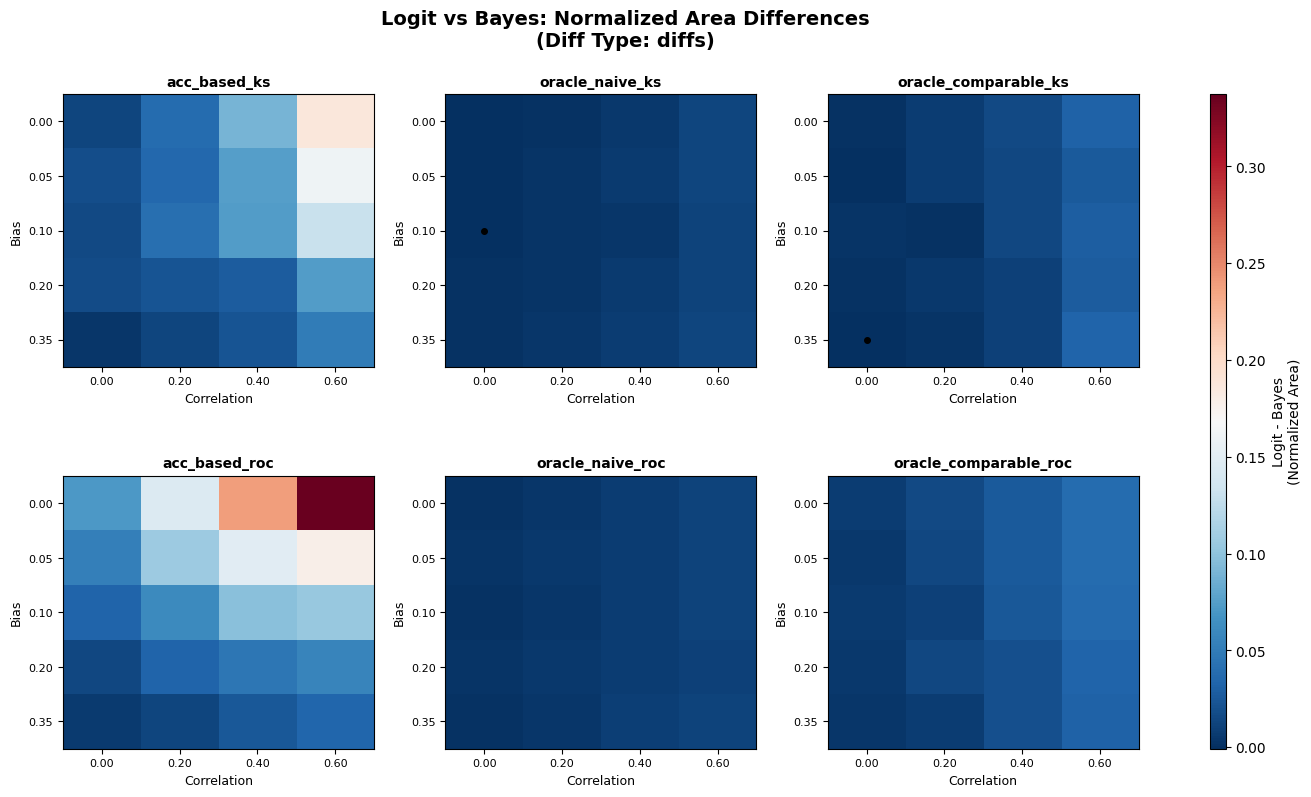

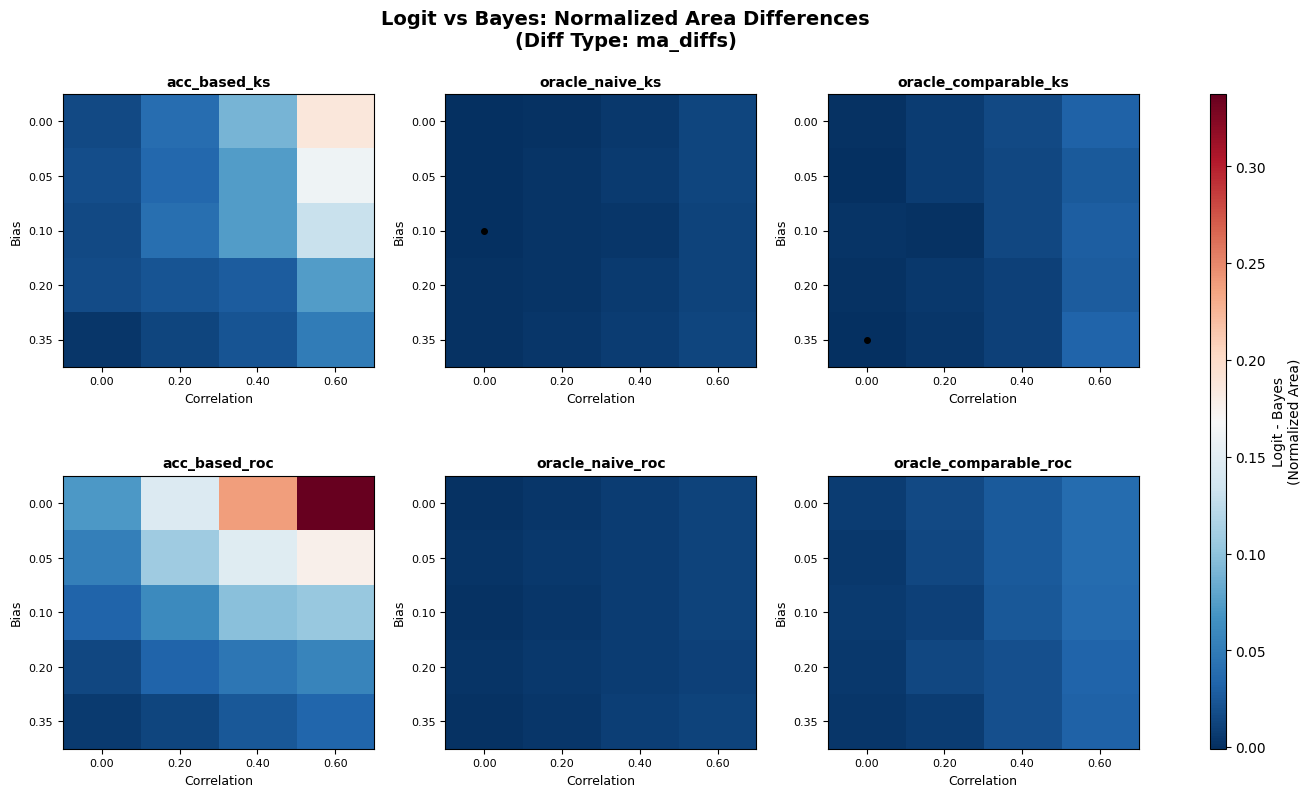

In [79]:
# === REFACTORED PIPELINE USING FUNCTIONS ===

# Step 1: Extract logit - bayes differences
logit_area_minus_bayes_normed = normed_areas[..., 0, :] - normed_areas[..., 1, :]

# Step 2: Create the heatmap visualization
plot_heatmap_grid(
    data=logit_area_minus_bayes_normed,
    metric_categories=METRIC_CATEGORIES,
    expectation_types=EXPECTATION_TYPES,
    diff_types=diff_types,
    biases=biases,
    corrs=corrs,
    cmap='RdBu_r',
    suptitle='Logit vs Bayes: Normalized Area Differences',
    title_bold=True,
    cbar_label='Logit - Bayes\n(Normalized Area)',
    title_mapping=None  # Use default: f'{e_type}_{m_cat}'
)

# Complete Refactored Pipeline Example

This demonstrates using all helper functions together (alternative to existing cells 6-12):

In [ ]:
# --- Example: Using refactored functions for complete pipeline ---
# (Uncomment to run this alternative to cells 6-12)

# """
# # Extract biases and correlations from directory names
# biases_new, corrs_new = extract_biases_and_corrs_from_dirnames(grid_path)

# # Construct all_diffs tensor
# all_diffs_new, B, Co, E, M, D = construct_all_diffs_tensor(
#     grid_path=grid_path,
#     biases=biases_new,
#     corrs=corrs_new,
#     expectation_types=EXPECTATION_TYPES,
#     metric_categories=METRIC_CATEGORIES,
#     diff_types=diff_types,
#     sample_sizes=sample_sizes
# )

# # Get areas
# areas_new = get_areas(all_diffs_new, sample_sizes, METRIC_CATEGORIES)

# # Normalize areas
# normed_areas_new = normalize_areas(areas_new, METRIC_CATEGORIES, sample_sizes)

# # Compute logit - bayes difference
# logit_area_minus_bayes_normed_new = normed_areas_new[..., 0, :] - normed_areas_new[..., 1, :]

# # Visualize with custom title mapping
# def custom_title_mapping(e_type: str, m_cat: str) -> str:
#     return f'{e_type.upper()} - {m_cat.upper()} Metric'

# plot_heatmap_grid(
#     data=logit_area_minus_bayes_normed_new,
#     metric_categories=METRIC_CATEGORIES,
#     expectation_types=EXPECTATION_TYPES,
#     diff_types=diff_types,
#     biases=biases_new,
#     corrs=corrs_new,
#     cmap='RdBu_r',
#     suptitle='Custom Pipeline Example',
#     title_bold=True,
#     cbar_label='Logit - Bayes\n(Normalized Area)',
#     title_mapping=custom_title_mapping
# )
# """

# Function Documentation

## Summary of Refactored Functions

### 1. `extract_biases_and_corrs_from_dirnames(dir_path)`
Extracts bias and correlation dictionaries from directory names in a given path.
- **Input:** Path to simulation directory
- **Output:** Tuple of (biases_dict, corrs_dict)

### 2. `construct_all_diffs_tensor(...)`
Constructs the all_diffs tensor by iterating over parameter combinations and extracting differences.
- **Input:** grid_path, biases, corrs, expectation_types, metric_categories, diff_types, sample_sizes
- **Output:** Tuple of (all_diffs_tensor, B, Co, E, M, D)
- **Shape:** [B, Co, E, M, Cl=2, D, N]

### 3. `get_areas(all_diffs, sample_sizes, metric_categories)`
Computes areas under curves using masked trapezoidal integration.
- **Input:** all_diffs tensor, sample sizes, metric categories
- **Output:** Areas tensor of shape [B, Co, E, M, Cl, D]

### 4. `normalize_areas(areas, metric_categories, sample_sizes)`
Normalizes areas by worst-case areas for each metric category.
- **Input:** areas tensor, metric categories, sample sizes
- **Output:** Normalized areas tensor of shape [B, Co, E, M, Cl, D]

### 5. `plot_heatmap_grid(...)`
Creates and displays a grid of heatmaps with customizable options.
- **Key Parameters:**
  - `suptitle`: Super title (None or empty string = no suptitle)
  - `title_bold`: Whether subplot titles are bold
  - `cbar_label`: Colorbar label
  - `title_mapping`: Optional callable to customize subplot titles as f(expectation_type, metric_category)
  - `cmap`: Colormap (default: 'RdBu_r')
- **Features:**
  - Uses GridSpec for proper layout (eliminates tight_layout warning)
  - Adds black dots to negative values
  - Creates separate figure for each diff_type
  - Uniform colorbar across all subplots